## ACADEMY STOCK PREDICTION

In [2]:
import pandas as pd

academy=pd.read_csv('../stock_data/ACADEMY.csv')
academy

,id,symbol,trade_date,open_price,high_price,low_price,close_price,volume,created_at
0,42861,ACADEMY,2017-01-03,0.5,NaN,NaN,0.5,0,2026-04-08T02:41:25.765521+00:00
1,43421,ACADEMY,2017-01-04,0.5,NaN,NaN,0.5,0,2026-04-08T02:42:20.164398+00:00
2,43531,ACADEMY,2017-01-05,0.5,NaN,NaN,0.5,0,2026-04-08T02:42:22.380516+00:00
3,43641,ACADEMY,2017-01-06,0.5,NaN,NaN,0.5,0,2026-04-08T02:42:23.84796+00:00
4,43731,ACADEMY,2017-01-09,0.5,NaN,NaN,0.5,0,2026-04-08T02:42:26.938159+00:00
...,...,...,...,...,...,...,...,...,...
2258,298018,ACADEMY,2026-07-13,6.4,NaN,NaN,6.4,79314,2026-07-13T15:10:02.995074+00:00
2259,298456,ACADEMY,2026-07-14,6.4,NaN,NaN,6.4,265068,2026-07-14T15:10:03.094441+00:00
2260,298894,ACADEMY,2026-07-15,6.4,NaN,NaN,6.4,661525,2026-07-15T15:10:03.078609+00:00
2261,299332,ACADEMY,2026-07-16,6.4,NaN,NaN,6.4,198493,2026-07-16T15:10:03.113936+00:00


In [3]:
academy=academy.drop(columns=['high_price','low_price'])

In [4]:
academy.rename(columns={'trade_date':'date'},inplace=True)

In [5]:
academy['date']=pd.to_datetime(academy['date'])
academy.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           2263 non-null   int64         
 1   symbol       2263 non-null   str           
 2   date         2263 non-null   datetime64[us]
 3   open_price   2262 non-null   float64       
 4   close_price  2263 non-null   float64       
 5   volume       2263 non-null   int64         
 6   created_at   2263 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 123.9 KB


In [6]:
academy['month']=academy['date'].dt.month
academy['quarter']=academy['date'].dt.quarter
academy['year']=academy['date'].dt.year

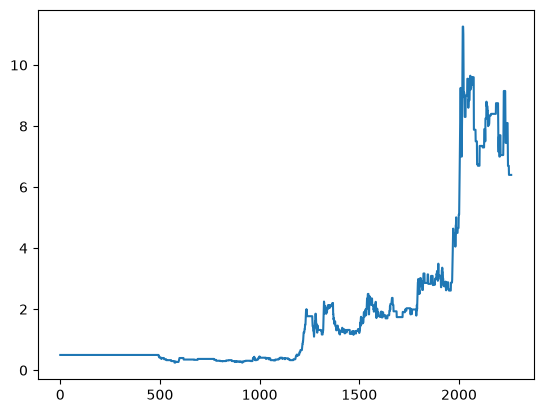

In [7]:
import matplotlib.pyplot as plt

plt.plot(academy['close_price'])
plt.show()

In [8]:
academy_end_month_df = (
    academy
    .sort_values("date")
    .groupby(academy["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

academy_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45431,ACADEMY,2017-01-31,0.50,0.50,500,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47254,ACADEMY,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49370,ACADEMY,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51197,ACADEMY,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53120,ACADEMY,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35255,ACADEMY,2026-03-31,8.75,8.75,341298,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281082,ACADEMY,2026-04-30,7.05,7.05,848869,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284148,ACADEMY,2026-05-29,9.15,9.15,62957,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294076,ACADEMY,2026-06-30,6.70,6.70,18719,2026-06-30T15:10:03.08168+00:00,6,2,2026


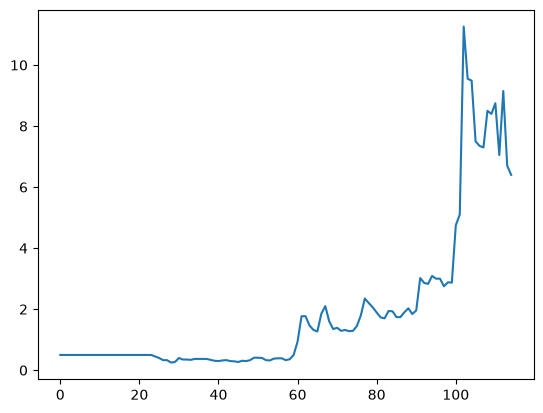

In [9]:
plt.plot(academy_end_month_df['close_price'])
plt.show()

In [10]:
academy_end_month_df['returns']=academy_end_month_df['close_price'].pct_change()*100
academy_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45431,ACADEMY,2017-01-31,0.50,0.50,500,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47254,ACADEMY,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49370,ACADEMY,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51197,ACADEMY,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53120,ACADEMY,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35255,ACADEMY,2026-03-31,8.75,8.75,341298,2026-03-31T15:00:02.085058+00:00,3,1,2026,4.166667
111,281082,ACADEMY,2026-04-30,7.05,7.05,848869,2026-04-30T15:00:02.170664+00:00,4,2,2026,-19.428571
112,284148,ACADEMY,2026-05-29,9.15,9.15,62957,2026-05-29T15:00:02.455558+00:00,5,2,2026,29.787234
113,294076,ACADEMY,2026-06-30,6.70,6.70,18719,2026-06-30T15:10:03.08168+00:00,6,2,2026,-26.775956


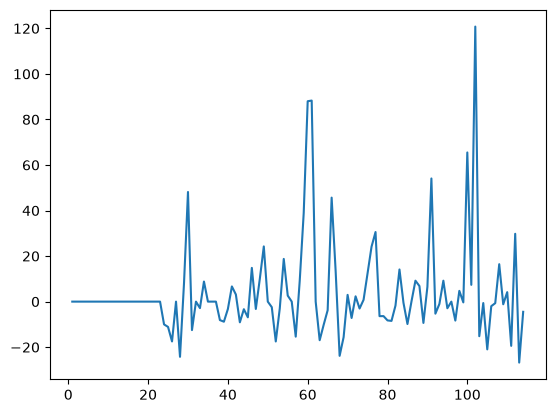

In [11]:
plt.plot(academy_end_month_df['returns'])
plt.show()

In [12]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(academy_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-6.858642258438819), np.float64(1.6238211447358177e-09), 2, 111, {'1%': np.float64(-3.490683082754047), '5%': np.float64(-2.8879516565798817), '10%': np.float64(-2.5808574442009578)}, np.float64(906.2948323422734))
stationary


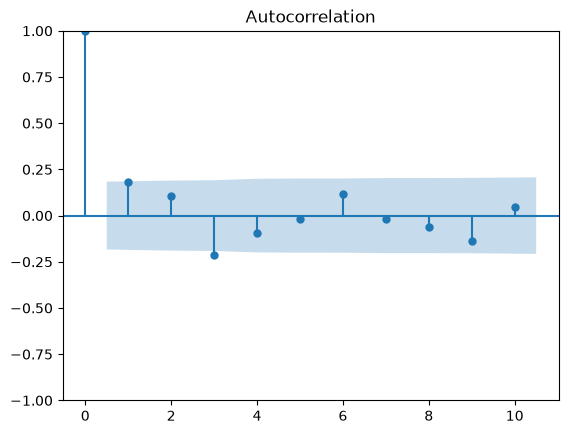

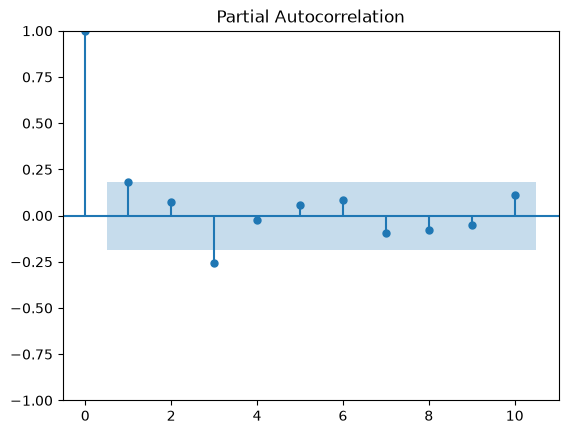

In [13]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(academy_end_month_df['returns'].dropna(), lags=10)
plot_pacf(academy_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [14]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [15]:
train=academy_end_month_df['close_price'][:-10]
test=academy_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -76.51448062813746]
[0, 0, 0, 0, 0, 1, -41.44631179956072]
[0, 0, 0, 0, 0, 2, -35.83578400615799]
[0, 0, 0, 0, 1, 0, -27.071553610503276]
[0, 0, 0, 0, 1, 1, -28.11372202276193]
[0, 0, 0, 0, 1, 2, -29.485941279091755]
[0, 0, 0, 0, 2, 0, -39.081670742398046]
[0, 0, 0, 0, 2, 1, -29.711209957232505]
[0, 0, 0, 0, 2, 2, -22.34986865950246]
[0, 0, 0, 1, 0, 0, -29.765996293628508]
[0, 0, 0, 1, 0, 1, -29.264099596064483]
[0, 0, 0, 1, 0, 2, -29.65887351706752]
[0, 0, 0, 1, 1, 0, -27.59342962596395]
[0, 0, 0, 1, 1, 1, -26.372427227231306]
[0, 0, 0, 1, 1, 2, -23.82571772178343]
[0, 0, 0, 1, 2, 0, -31.136130659253027]
[0, 0, 0, 1, 2, 1, -28.682682923524553]
[0, 0, 0, 1, 2, 2, -34.69084499103605]
[0, 0, 0, 2, 0, 0, -29.206487132118326]
[0, 0, 0, 2, 0, 1, -29.991334795128584]
[0, 0, 0, 2, 0, 2, -29.996655881382736]
[0, 0, 0, 2, 1, 0, -26.486936460293087]
[0, 0, 0, 2, 1, 1, -25.615783317868114]
[0, 0, 0, 2, 1, 2, -28.583430177727507]
[0, 0, 0, 2, 2, 0, -27.886640889968838]
[0, 0, 0,

In [16]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-76.514481
168,0,2,0,0,2,0,-70.392843
222,0,2,2,0,2,0,-69.498834
27,0,0,1,0,0,0,-69.373804
666,2,2,0,2,0,0,-69.233645
...,...,...,...,...,...,...,...
540,2,0,2,0,0,0,0.101019
542,2,0,2,0,0,2,0.115722
558,2,0,2,2,0,0,0.179205
541,2,0,2,0,0,1,0.182794


not good enough. We will have to iterate another search for better performances. We will pin autocorrelation at `3`. To cut out repeating iterations.

In [17]:
train=academy_end_month_df['close_price'][:-10]
test=academy_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []

for i in range(4):
    for q in range(4):
        for P in range(4):
            for D in range(4):
                for Q in range(4):
                    try:
                        mod = SARIMAX(train, 
                        order=(3,i,q), seasonal_order=(P,D,Q,12))
                        res = mod.fit(disp=False)
                        fcst=res.forecast(steps=10)
                        score =  [3,i,q,P,D,Q,r2_score(test,fcst)]
                        print(score)
                        scores.append(score)
                        del mod
                        del res
                    except:
                        print('errored')


[3, 0, 0, 0, 0, 0, -0.6613581736167822]
[3, 0, 0, 0, 0, 1, -0.5282168945425458]
[3, 0, 0, 0, 0, 2, -0.38937116315857967]
[3, 0, 0, 0, 0, 3, -0.26350611633698917]
[3, 0, 0, 0, 1, 0, -8.141595730737892]
[3, 0, 0, 0, 1, 1, -3.4917086657476766]
[3, 0, 0, 0, 1, 2, -1.8969656863768032]
[3, 0, 0, 0, 1, 3, -2.3209211792047397]
[3, 0, 0, 0, 2, 0, -35.25302348979761]
[3, 0, 0, 0, 2, 1, -16.484408334728716]
[3, 0, 0, 0, 2, 2, -10.057687816671955]
[3, 0, 0, 0, 2, 3, -16.163445451798932]
[3, 0, 0, 0, 3, 0, -62.831071830912585]
[3, 0, 0, 0, 3, 1, -52.54059239868696]
[3, 0, 0, 0, 3, 2, -46.17320715243057]
[3, 0, 0, 0, 3, 3, -39.19248352083817]
[3, 0, 0, 1, 0, 0, -0.5042372181321131]
[3, 0, 0, 1, 0, 1, -0.5790958818966345]
[3, 0, 0, 1, 0, 2, -0.26486483775473557]
[3, 0, 0, 1, 0, 3, -0.2670171503062768]
[3, 0, 0, 1, 1, 0, -3.4946688741981253]
[3, 0, 0, 1, 1, 1, -2.6981875002119637]
[3, 0, 0, 1, 1, 2, -2.0179719418187854]
[3, 0, 0, 1, 1, 3, -2.1814874504250894]
[3, 0, 0, 1, 2, 0, -17.778892604799445]
[3

In [18]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
944,3,3,2,3,1,0,-4.789544e+13
946,3,3,2,3,1,2,-1.643473e+12
916,3,3,2,1,1,2,-3.498189e+08
829,3,3,0,3,3,3,-2.557585e+03
775,3,3,0,0,2,0,-2.552258e+03
...,...,...,...,...,...,...,...
65,3,0,1,0,0,1,1.556606e-01
96,3,0,1,2,0,0,1.598342e-01
98,3,0,1,2,0,2,1.645005e-01
81,3,0,1,1,0,1,1.667260e-01


It didnt get any better. We will stick with the first iterations. The best is [2	0	2	1	0	0]

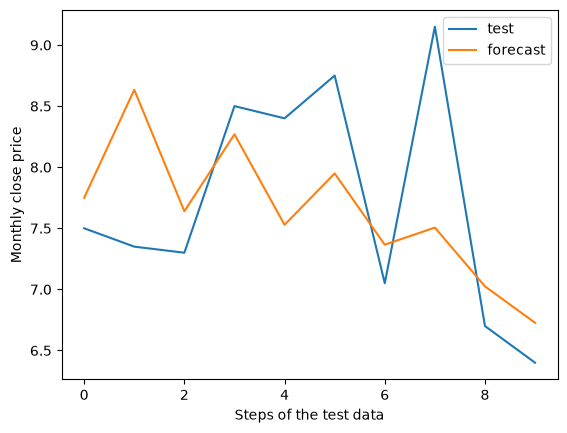

0.1896238019538682
0.7934615732737408


In [23]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=academy_end_month_df['close_price'][:-10]
y_test=academy_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,2), 
seasonal_order=(1,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print(r2_score(y_test, fcst))
print(np.sqrt(mean_squared_error(y_test,fcst)))

In [20]:
academy_end_month_df.close_price.describe()

count    115.000000
mean       1.916435
std        2.504962
min        0.250000
25%        0.395000
50%        0.500000
75%        1.995000
max       11.260000
Name: close_price, dtype: float64

Not good enough but we have to move on.